<a href="https://colab.research.google.com/github/Ayushman2005-cmyk/AML_EXPERIMENTS/blob/main/AML_LAB4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [32]:
data = {
    'Student_ID': ['S1', 'S2', 'S3'],
    'X': [1, 2, 3],
    'Y': [2, 3, 4]
}
df = pd.DataFrame(data)
df

,Student_ID,X,Y
0,S1,1,2
1,S2,2,3
2,S3,3,4


In [33]:
X = df['X'].values.astype(float)
Y = df['Y'].values.astype(float)
m = len(X)
print(f"Number of training instances (m): {m}")
print(f"X: {X}")
print(f"Y: {Y}")

Number of training instances (m): 3
X: [1. 2. 3.]
Y: [2. 3. 4.]


In [34]:
def compute_cost(X, Y, w, b):
    m = len(X)
    predictions = w * X + b
    cost = (1 / (2 * m)) * np.sum((predictions - Y) ** 2)
    return cost

def gradient_descent(X, Y, w, b, learning_rate, iterations):
    m = len(X)
    cost_history = []
    w_history = []
    b_history = []

    for i in range(iterations):
        predictions = w * X + b
        dw = (1 / m) * np.sum((predictions - Y) * X)
        db = (1 / m) * np.sum(predictions - Y)

        w = w - learning_rate * dw
        b = b - learning_rate * db

        cost = compute_cost(X, Y, w, b)
        cost_history.append(cost)
        w_history.append(w)
        b_history.append(b)

    return w, b, cost_history, w_history, b_history

In [35]:
w_init = 0.0
b_init = 0.0
learning_rate = 0.1
iterations = 3

w_final, b_final, cost_history, w_history, b_history = gradient_descent(
    X, Y, w_init, b_init, learning_rate, iterations
)

print(f"Final weight (slope) w = {w_final:.4f}")
print(f"Final bias (intercept) b = {b_final:.4f}")
print(f"Final cost J = {cost_history[-1]:.8f}")
print(f"Learned regression equation: Y = {w_final:.4f} * X + {b_final:.4f}")


Final weight (slope) w = 1.0925
Final bias (intercept) b = 0.5006
Final cost J = 0.05227923
Learned regression equation: Y = 1.0925 * X + 0.5006


In [36]:
print(f"Cost values for {iterations} iterations:")
for i, cost in enumerate(cost_history):
    print(f"Iteration {i+1}: Cost J = {cost:.2f}")

Cost values for 3 iterations:
Iteration 1: Cost J = 0.97
Iteration 2: Cost J = 0.20
Iteration 3: Cost J = 0.05


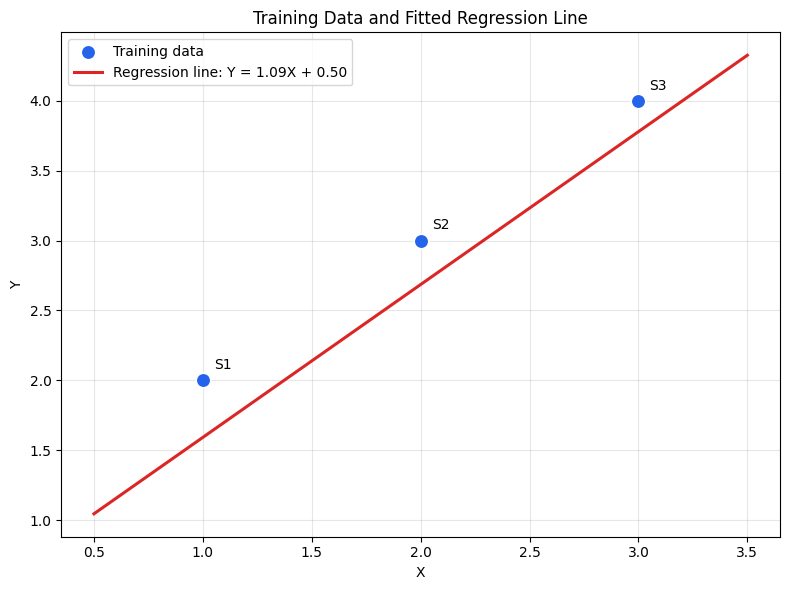

In [37]:
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, color='#2563eb', s=110, edgecolor='white', linewidth=1.2,
            zorder=3, label='Training data')
for i, sid in enumerate(df['Student_ID']):
    plt.annotate(sid, (X[i], Y[i]), textcoords="offset points", xytext=(8, 8), fontsize=10)

X_line = np.linspace(X.min() - 0.5, X.max() + 0.5, 100)
Y_line = w_final * X_line + b_final
plt.plot(X_line, Y_line, color='#dc2626', linewidth=2.2,
         label=f'Regression line: Y = {w_final:.2f}X + {b_final:.2f}')

plt.xlabel('X')
plt.ylabel('Y')
plt.title('Training Data and Fitted Regression Line')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


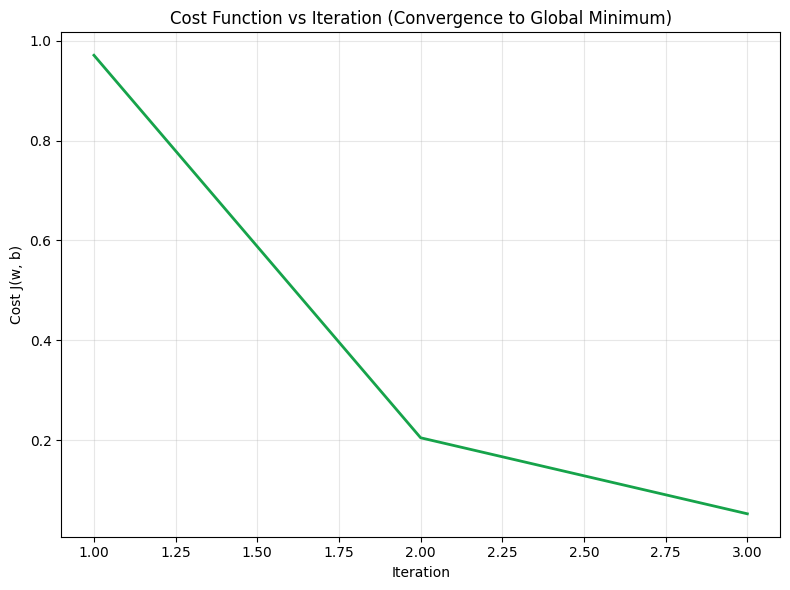

In [38]:
plt.figure(figsize=(8, 6))
plt.plot(range(1, iterations + 1), cost_history, color='#16a34a', linewidth=2)
plt.xlabel('Iteration')
plt.ylabel('Cost J(w, b)')
plt.title('Cost Function vs Iteration (Convergence to Global Minimum)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()